# Bagging (Bootstrap Aggregating)

Bagging is a machine learning technique that combines multiple models to improve the accuracy of the final model. It works by creating multiple subsets of the training data and training a model on each subset. The final model is then the average of the models trained on each subset.

## Core Components:

- Bootstrapping
- Diversity + Wisdom of the Crowd
- Majority Voting

> Bagging algorithm **works well with high-variance models** (complex models) and average-out the noise and errors of the models, results in more **robust** and accurate predictions.

## Performance Monitoring

- Train-Test Score
- Cross-Validation
- OOB Score
- Individual Model Scores

## Advantages:

- Makes robust predictions by combining the predictions of multiple models.
- Reduces variance so improves the accuracy of predictions by averaging the predictions of multiple models.
- Prevents overfitting by reducing the variance of the model.

## Disadvantages:

- Requires more computational resources to train the models.
- Can be unstable when the models are not well-tuned.
- Can be sensitive to the choice of the base estimator.
- Prediction time can be a big challenge in real-world problems like using your model in an app than customers use it for a certain estimation.

> Increasing the number of models improves the predictive performace but increases the computational cost, be aware of the trade-off between them.

### Example of bagging ensemble

In [86]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [54]:
# load data
data = load_wine()

X, y = data.data, data.target

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# usefull datasets
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# train and evaluate base models
dt = DecisionTreeClassifier()
knn = KNeighborsClassifier()

models = [dt, knn]
model_names = ["Decision Tree", "K-Nearest Neighbors"]

for model, name in zip(models, model_names):
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name} CV score: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Decision Tree CV score: 0.915 ± 0.018
K-Nearest Neighbors CV score: 0.662 ± 0.036


In [56]:
base_estimator = DecisionTreeClassifier(random_state=42)
bagging_model = BaggingClassifier(
    estimator=base_estimator,
    n_estimators=100,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

bagging_model.fit(X_scaled, y)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.8
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",0.8
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [ ]:
oob_score = bagging_model.oob_score_
cv_scores = cross_val_score( # cross validation to get the CV score
    estimator=bagging_model,
    X=X,
    y=y,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
)

print(f"OOB Score: {oob_score:.3f}")
print(f"CV Score: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

OOB Score: 0.978
CV Score: 0.967 +/- 0.021


In [58]:
import pandas as pd

# we have imbalanced data
test = pd.DataFrame(data.target).value_counts().to_frame()
test / test.sum() * 100

,count
0,
1,39.887640
0,33.146067
2,26.966292


In [59]:
def tune_bagging_params(base_estimator, param_grid, X, y):    
    grid = GridSearchCV(
        estimator=base_estimator,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
	)
    grid.fit(X, y)
    
    return grid.best_params_

param_grid = {
    "n_estimators": [10, 50, 100, 300],
}

tune_bagging_params(bagging_model, param_grid, X_train, y_train)

{'n_estimators': 50}

In [88]:
def train_bagging_model_pipeline(X: np.array, y: np.array) -> Pipeline:
	""" Trains a bagging model pipeline.

	This function trains a bagging model pipeline using the given training data and labels. The pipeline
	consists of a standard scaler and a bagging classifier that its base model is a decision tree classifier.
	The pipeline is then trained on the training data and labels, and the accuracy, cross-validation score,
	and out-of-bag score are printed.

	:param X: Training data.
	:param y: Training labels.
	:return: Trained pipeline.
	"""
	pipe = Pipeline(
		steps=[
			('scaler', StandardScaler()),
			('clf', BaggingClassifier(
				estimator=DecisionTreeClassifier(),
				n_estimators=100,
				max_samples=0.8,
				max_features=0.8,
				bootstrap=True,
				oob_score=True,
				n_jobs=-1,
			)),
		]
	)
	pipe.fit(X, y)

	y_pred_train = pipe.predict(X_train_scaled)
	y_pred_test = pipe.predict(X_test_scaled)
	cv_scores = cross_val_score(pipe, X_train_scaled, y_train, cv=5)

	print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train)}")
	print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test)}")
	print(f"CV Score: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
	print(f"OOB Score: {pipe.named_steps['clf'].oob_score_:.3f}")

	return pipe

bagging = train_bagging_model_pipeline(X_train_scaled, y_train)
bagging

Training Accuracy: 1.0
Test Accuracy: 1.0
CV Score: 0.957 +/- 0.042
OOB Score: 0.972


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


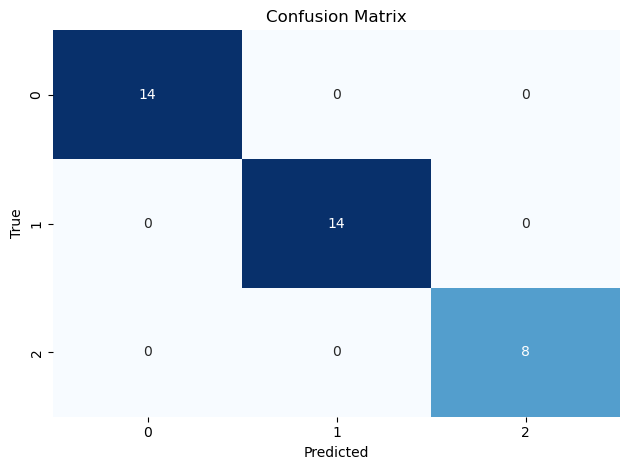

In [100]:
def plot_confusion_matrix():
	y_pred = bagging.predict(X_test_scaled)
	cm = confusion_matrix(y_test, y_pred)

	ax = sns.heatmap(cm, annot=True, cmap='Blues', cbar=False)
	ax.set(
		title='Confusion Matrix',
		xlabel='Predicted',
		ylabel='True'
	)
	plt.tight_layout()
	plt.show()

plot_confusion_matrix()